# Feature EDA & QA

This notebook audits rolling features (R3, R5) and checks for leakage, missing data, and calibration.

In [44]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import duckdb
import yaml
from pathlib import Path

try:
    import missingno as msno
    HAS_MISSINGNO = True
except ImportError:
    HAS_MISSINGNO = False

# Load df from DuckDB (feature_store + raw_matches)
def find_config(start: Path) -> Path:
    for parent in [start] + list(start.parents):
        candidate = parent / 'config.yaml'
        if candidate.exists():
            return candidate
    raise FileNotFoundError('config.yaml not found. Run from repo root or update path.')

config_path = find_config(Path.cwd())
with config_path.open('r', encoding='utf-8') as handle:
    config = yaml.safe_load(handle) or {}
db_rel = Path(config.get('paths', {}).get('database_path', 'data/fpai_core.db'))
db_path = db_rel if db_rel.is_absolute() else config_path.parent / db_rel

with duckdb.connect(str(db_path)) as conn:
    df = conn.execute(
        """
        SELECT r.date, r.home_team, r.away_team, r.fthg, r.ftag,
               f.*
        FROM raw_matches r
        INNER JOIN feature_store f ON r.match_id = f.match_id
        WHERE r.league IN ('E0')
        ORDER BY r.date, r.match_id
        """
    ).fetchdf()

df['home_win'] = (df['fthg'] > df['ftag']).astype(int)

sns.set_style('whitegrid')

In [45]:
with duckdb.connect(str(db_path)) as conn:
    temp=conn.execute(
            """
            SELECT *
            FROM raw_matches
            """
        ).fetchdf()

In [46]:

with duckdb.connect(str(db_path)) as conn:
    temp=conn.execute(
            '''-- confirm you’re using the expected DB file
                SELECT current_database();

                -- check team names in raw_matches
                SELECT DISTINCT home_team
                FROM raw_matches
                WHERE home_team ILIKE '%man%';

                -- null check for Man City / Man United
                SELECT COUNT(*) AS total,
                    SUM(CASE WHEN ast IS NULL OR hc IS NULL OR ac IS NULL THEN 1 ELSE 0 END) AS missing
                FROM raw_matches
                WHERE date >= '2023-01-01' AND date < '2026-12-31'
                AND (home_team IN ('Manchester City','Manchester United')
                    OR away_team IN ('Manchester City','Manchester United'));'''
        ).fetchdf()



## Missing Value Audit

,nan_pct
MKT_IMPLIED_AWAY,30.636926
MKT_IMPLIED_DRAW,30.636926
MKT_IMPLIED_HOME,30.636926
DEF_AWAY_HST_R5,4.568664
OFF_HOME_SHOT_ACCURACY_R5,4.568664
...,...
DEF_AWAY_HST_R3,2.741199
OFF_HOME_HC_R3,2.741199
OFF_HOME_FTHG_R3,2.741199
CTX_HOME_REST_DAYS,0.913733


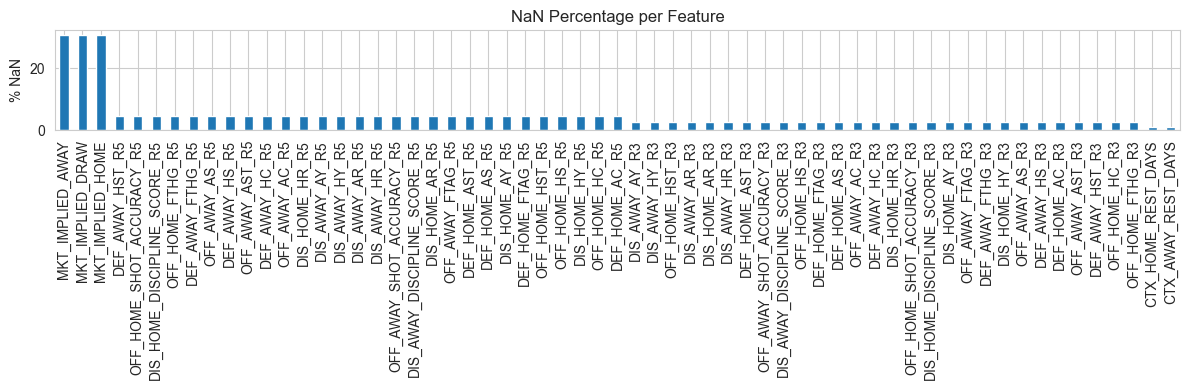

In [47]:
feature_cols = [c for c in df.columns if c.startswith(('OFF_', 'DEF_', 'DIS_', 'CTX_', 'MKT_'))]
target_col = 'home_win'

nan_pct = df[feature_cols].isna().mean().sort_values(ascending=False) * 100
display(nan_pct.to_frame('nan_pct'))

plt.figure(figsize=(12, 4))
nan_pct.plot(kind='bar')
plt.title('NaN Percentage per Feature')
plt.ylabel('% NaN')
plt.tight_layout()
plt.show()

if HAS_MISSINGNO:
    msno.bar(df[feature_cols], figsize=(12, 4))
    plt.show()

,OFF_HOME_FTHG_R3,OFF_HOME_FTHG_R5,DEF_HOME_FTAG_R3,DEF_HOME_FTAG_R5,OFF_HOME_HS_R3,OFF_HOME_HS_R5,DEF_HOME_AS_R3,DEF_HOME_AS_R5,OFF_HOME_HST_R3,OFF_HOME_HST_R5,...,DIS_AWAY_HR_R3,DIS_AWAY_HR_R5,OFF_AWAY_SHOT_ACCURACY_R3,OFF_AWAY_SHOT_ACCURACY_R5,DIS_AWAY_DISCIPLINE_SCORE_R3,DIS_AWAY_DISCIPLINE_SCORE_R5,CTX_AWAY_REST_DAYS,MKT_IMPLIED_HOME,MKT_IMPLIED_DRAW,MKT_IMPLIED_AWAY
season_year,,,,,,,,,,,,,,,,,,,,,
2016,31.914894,53.191489,31.914894,53.191489,31.914894,53.191489,31.914894,53.191489,31.914894,53.191489,...,31.914894,53.191489,31.914894,53.191489,31.914894,53.191489,10.638298,100.000000,100.000000,100.000000
2017,2.244389,3.740648,2.244389,3.740648,2.244389,3.740648,2.244389,3.740648,2.244389,3.740648,...,2.244389,3.740648,2.244389,3.740648,2.244389,3.740648,0.748130,100.000000,100.000000,100.000000
2018,2.425876,4.043127,2.425876,4.043127,2.425876,4.043127,2.425876,4.043127,2.425876,4.043127,...,2.425876,4.043127,2.425876,4.043127,2.425876,4.043127,0.808625,100.000000,100.000000,100.000000
2019,2.374670,3.957784,2.374670,3.957784,2.374670,3.957784,2.374670,3.957784,2.374670,3.957784,...,2.374670,3.957784,2.374670,3.957784,2.374670,3.957784,0.791557,47.493404,47.493404,47.493404
2020,0.892857,1.488095,0.892857,1.488095,0.892857,1.488095,0.892857,1.488095,0.892857,1.488095,...,0.892857,1.488095,0.892857,1.488095,0.892857,1.488095,0.297619,0.000000,0.000000,0.000000
2021,0.735294,1.225490,0.735294,1.225490,0.735294,1.225490,0.735294,1.225490,0.735294,1.225490,...,0.735294,1.225490,0.735294,1.225490,0.735294,1.225490,0.245098,0.000000,0.000000,0.000000
2022,0.831025,1.385042,0.831025,1.385042,0.831025,1.385042,0.831025,1.385042,0.831025,1.385042,...,0.831025,1.385042,0.831025,1.385042,0.831025,1.385042,0.277008,0.000000,0.000000,0.000000
2023,0.728155,1.213592,0.728155,1.213592,0.728155,1.213592,0.728155,1.213592,0.728155,1.213592,...,0.728155,1.213592,0.728155,1.213592,0.728155,1.213592,0.242718,0.000000,0.000000,0.000000
2024,0.806452,1.344086,0.806452,1.344086,0.806452,1.344086,0.806452,1.344086,0.806452,1.344086,...,0.806452,1.344086,0.806452,1.344086,0.806452,1.344086,0.268817,0.000000,0.000000,0.000000


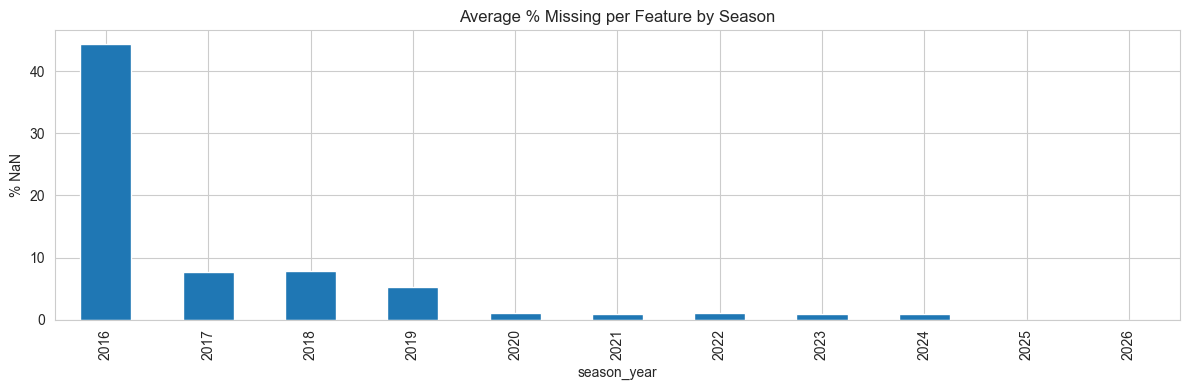

In [48]:
# Missing value rates by season (inferred from match date)
season_year = pd.to_datetime(df['date'], errors='coerce').dt.year
df_season = df.copy()
df_season['season_year'] = season_year

season_missing = (
    df_season
    .groupby('season_year')[feature_cols]
    .apply(lambda g: g.isna().mean() * 100)
)

display(season_missing)

plt.figure(figsize=(12, 4))
season_missing.mean(axis=1).plot(kind='bar')
plt.title('Average % Missing per Feature by Season')
plt.ylabel('% NaN')
plt.tight_layout()
plt.show()


## 100% Missing Feature Investigation

In [49]:
all_nan_features = nan_pct[nan_pct == 100.0].index.tolist()
if not all_nan_features:
    print('No features with 100% missing values detected.')
else:
    print('Features with 100% missing values:')
    display(pd.DataFrame({'feature': all_nan_features}))

    likely_causes = []
    for feat in all_nan_features:
        if 'SHOT_ACCURACY' in feat:
            likely_causes.append((feat, 'Missing HS/HST or AS/AST inputs in raw_matches'))
        elif 'DISCIPLINE_SCORE' in feat:
            likely_causes.append((feat, 'Missing HY/HR or AY/AR inputs in raw_matches'))
        elif feat.startswith('MKT_'):
            likely_causes.append((feat, 'Missing AvgH/AvgD/AvgA inputs in raw_matches'))
        elif 'REST_DAYS' in feat:
            likely_causes.append((feat, 'Only one match per team in data or missing date values'))
    if likely_causes:
        display(pd.DataFrame(likely_causes, columns=['feature', 'possible_cause']))

    print('Available columns in df (raw + features):')
    display(pd.DataFrame({'columns': sorted(df.columns)}))


No features with 100% missing values detected.


In [50]:
# Investigate missing MKT implied probs by checking raw avg odds inputs
mkt_cols = ['MKT_IMPLIED_HOME', 'MKT_IMPLIED_DRAW', 'MKT_IMPLIED_AWAY']

with duckdb.connect(str(db_path)) as conn:
    audit = conn.execute(
        """
        SELECT r.match_id, r.league, r.date, r.home_team, r.away_team,
               r.avgh, r.avgd, r.avga,
               f.MKT_IMPLIED_HOME, f.MKT_IMPLIED_DRAW, f.MKT_IMPLIED_AWAY
        FROM raw_matches r
        LEFT JOIN feature_store f ON r.match_id = f.match_id
        WHERE r.league IN ('E0')
        """
    ).fetchdf()

for col in ['avgh','avgd','avga'] + mkt_cols:
    audit[col] = pd.to_numeric(audit[col], errors='coerce')

missing_mkt = audit[mkt_cols].isna().any(axis=1)
missing_inputs = audit[['avgh','avgd','avga']].isna().any(axis=1)

summary = pd.DataFrame({
    'total_rows': [len(audit)],
    'mkt_missing_rows': [int(missing_mkt.sum())],
    'avg_odds_missing_rows': [int(missing_inputs.sum())],
    'mkt_missing_due_to_avg_odds_missing': [int((missing_mkt & missing_inputs).sum())],
    'mkt_missing_with_avg_odds_present': [int((missing_mkt & ~missing_inputs).sum())],
}).T
summary.columns = ['count']
display(summary)

if (missing_mkt & missing_inputs).any():
    print('Example rows where MKT implied is missing because AvgH/AvgD/AvgA are missing:')
    display(audit.loc[missing_mkt & missing_inputs, ['date','home_team','away_team','avgh','avgd','avga']].head(10))

if (missing_mkt & ~missing_inputs).any():
    print('Rows where MKT implied is missing even though AvgH/AvgD/AvgA exist (check feature calc/join):')
    display(audit.loc[missing_mkt & ~missing_inputs, ['date','home_team','away_team','avgh','avgd','avga'] + mkt_cols].head(10))


,count
total_rows,3721
mkt_missing_rows,1140
avg_odds_missing_rows,1140
mkt_missing_due_to_avg_odds_missing,1140
mkt_missing_with_avg_odds_present,0


Example rows where MKT implied is missing because AvgH/AvgD/AvgA are missing:


,date,home_team,away_team,avgh,avgd,avga
0,2016-08-13,Hull,Leicester,NaN,NaN,NaN
1,2016-08-13,Middlesbrough,Stoke,NaN,NaN,NaN
2,2016-08-13,Crystal Palace,West Brom,NaN,NaN,NaN
3,2016-08-13,Manchester City,Sunderland,NaN,NaN,NaN
4,2016-08-13,Southampton,Watford,NaN,NaN,NaN
5,2016-08-13,Burnley,Swansea,NaN,NaN,NaN
6,2016-08-13,Everton,Tottenham,NaN,NaN,NaN
7,2016-08-14,Bournemouth,Manchester United,NaN,NaN,NaN
8,2016-08-14,Arsenal,Liverpool,NaN,NaN,NaN
9,2016-08-15,Chelsea,West Ham,NaN,NaN,NaN


## Distribution Analysis (OFF_/DEF_)

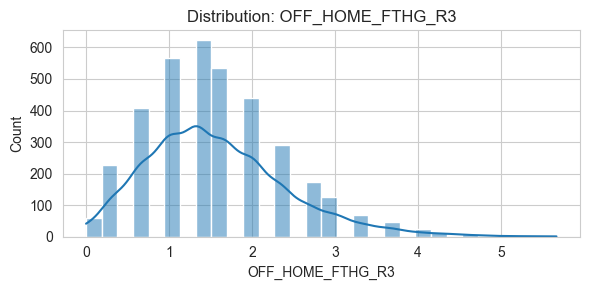

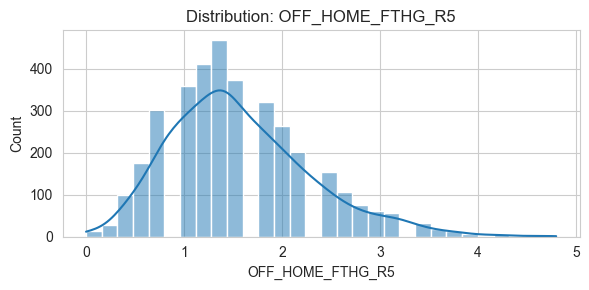

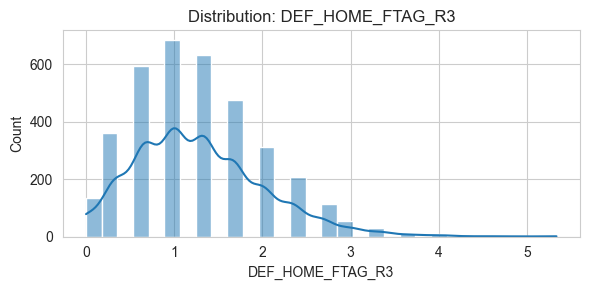

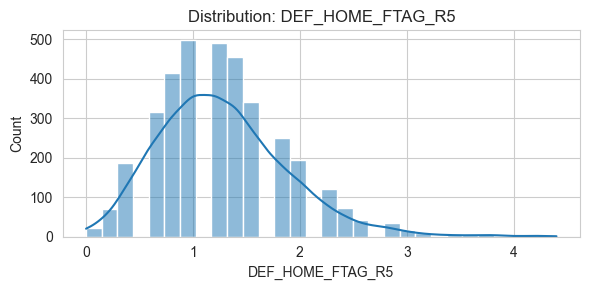

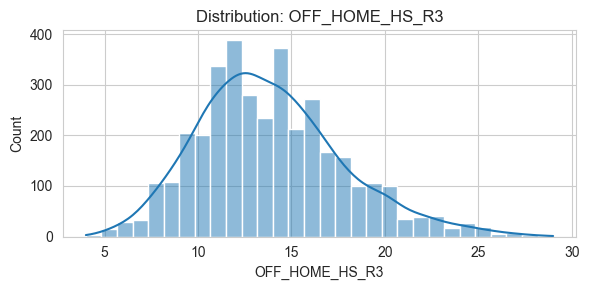

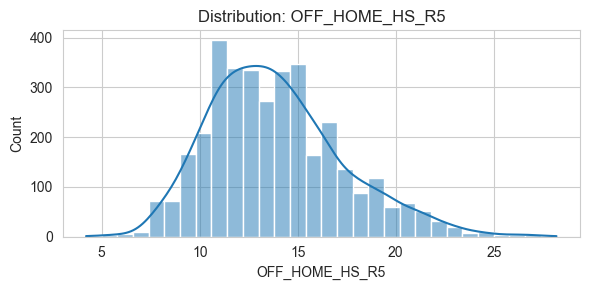

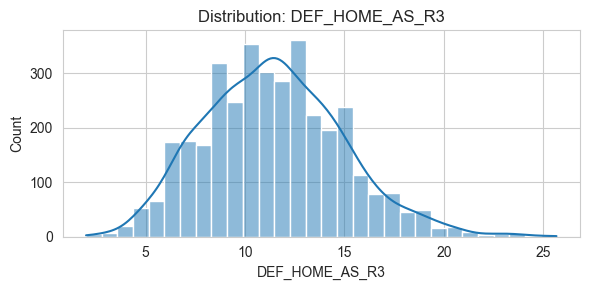

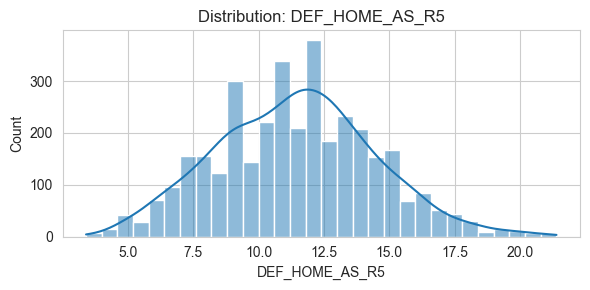

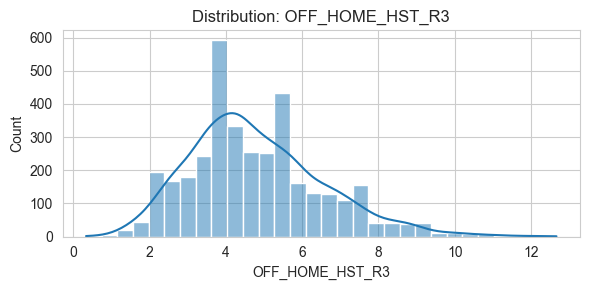

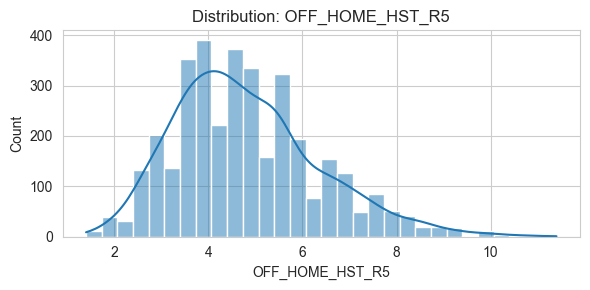

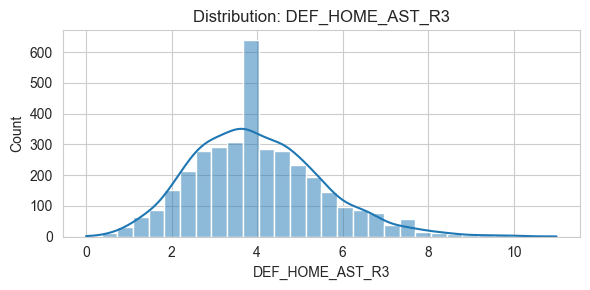

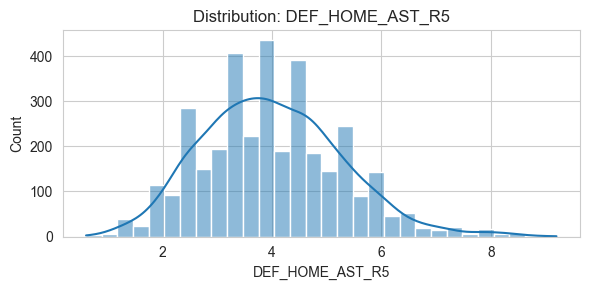

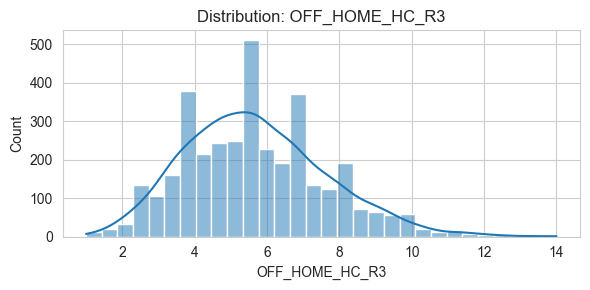

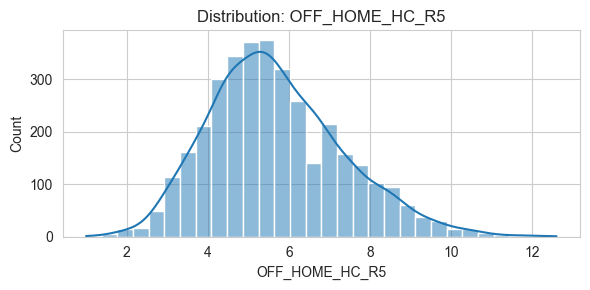

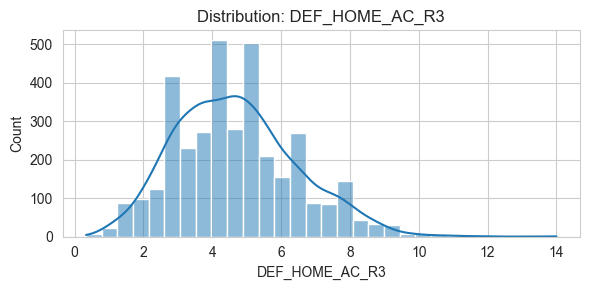

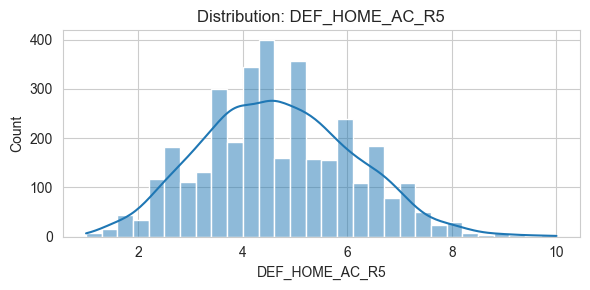

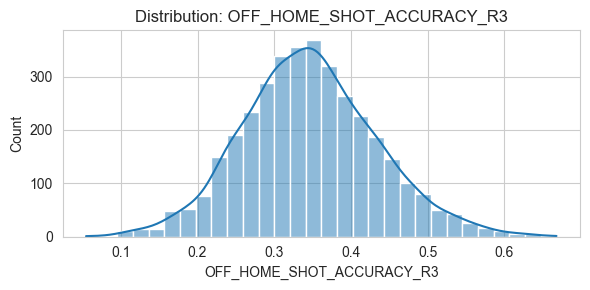

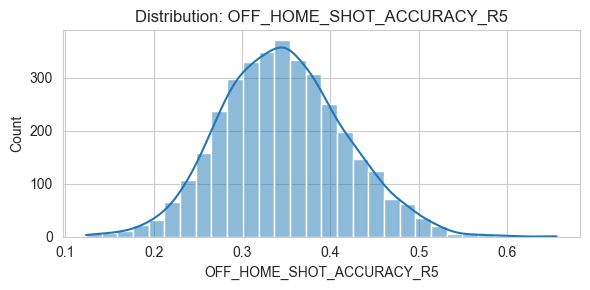

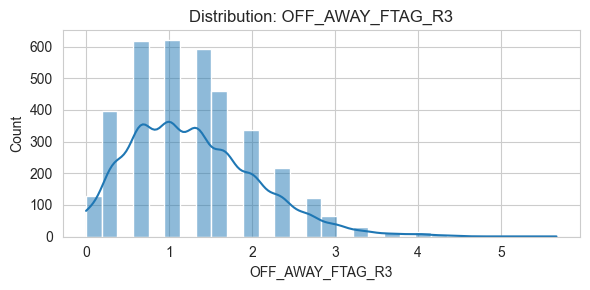

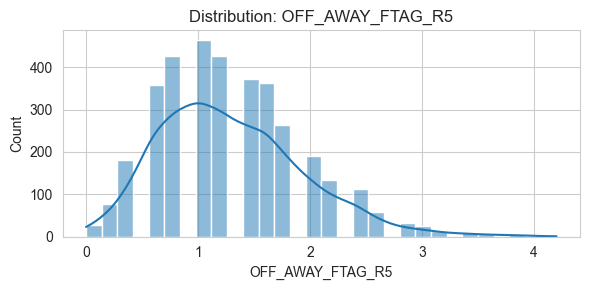

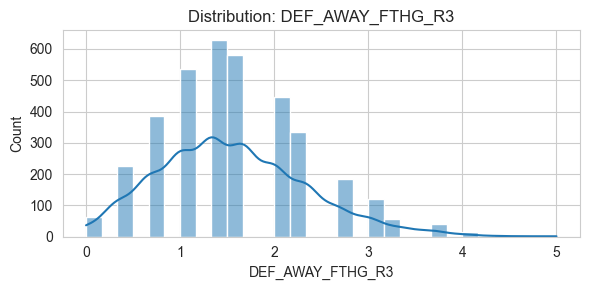

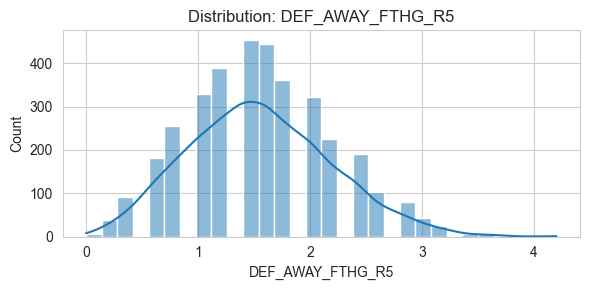

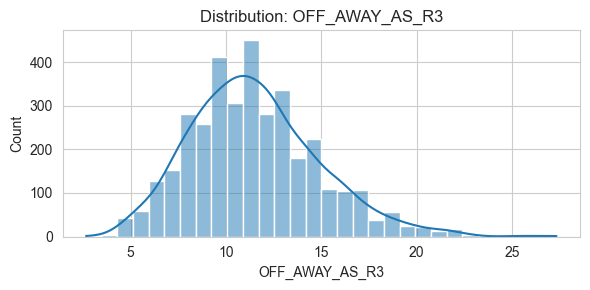

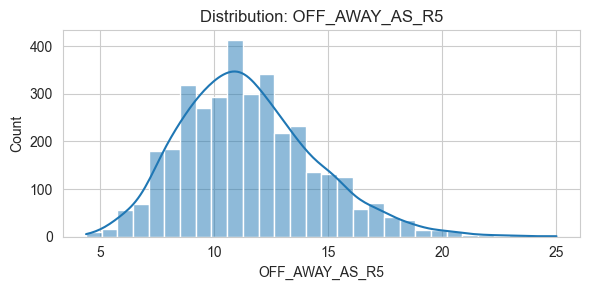

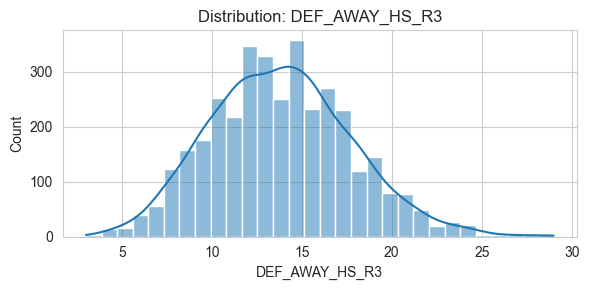

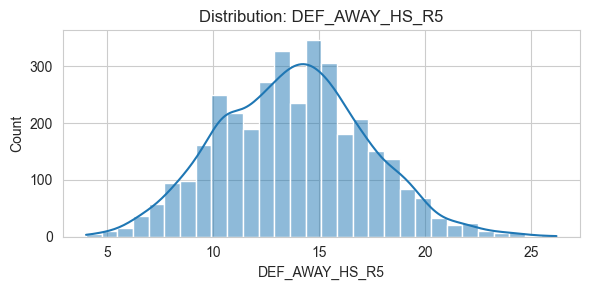

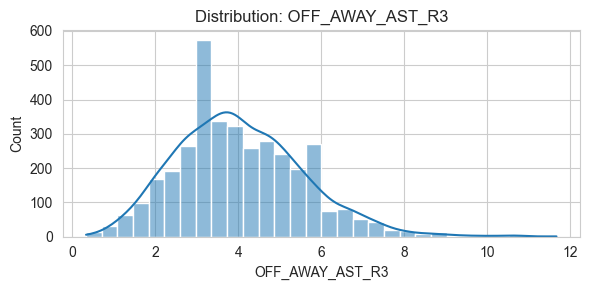

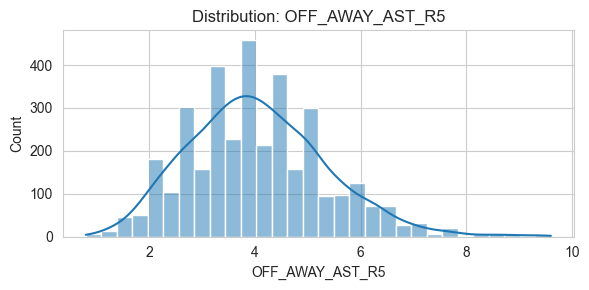

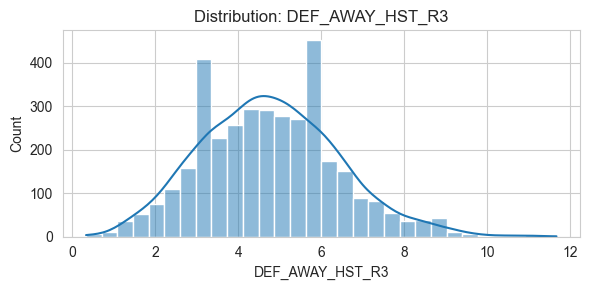

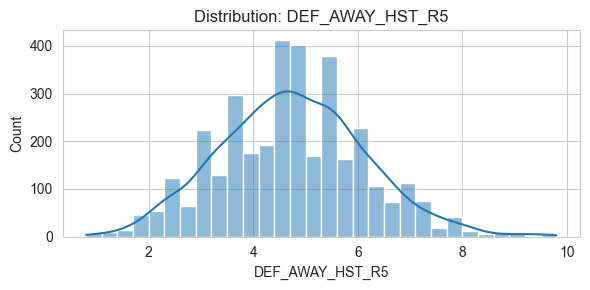

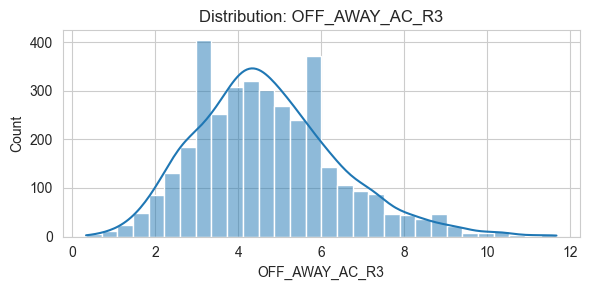

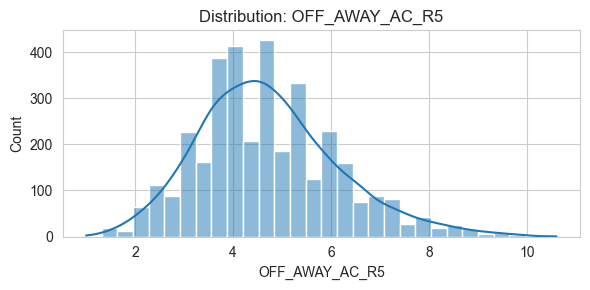

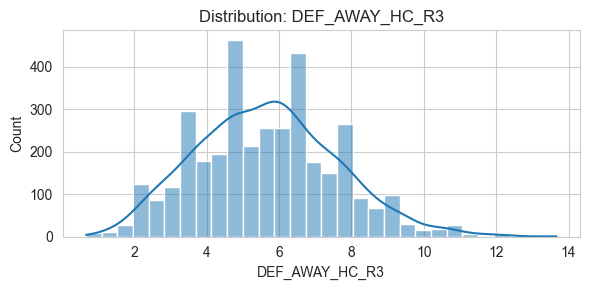

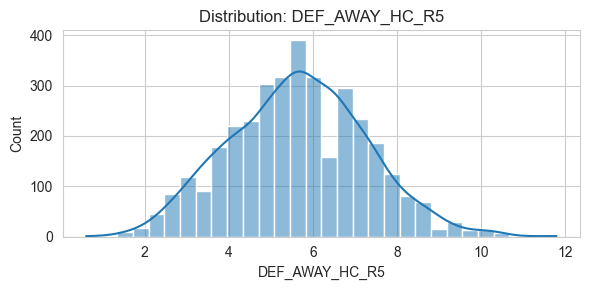

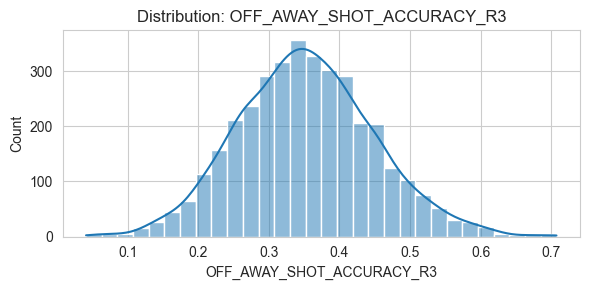

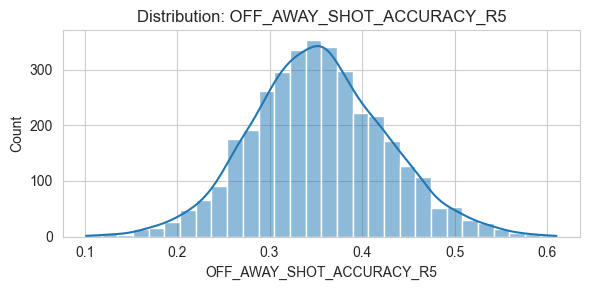

In [51]:
off_def_cols = [c for c in feature_cols if c.startswith(('OFF_', 'DEF_'))]

for col in off_def_cols:
    plt.figure(figsize=(6, 3))
    sns.histplot(df[col].dropna(), kde=True, bins=30)
    plt.title(f'Distribution: {col}')
    plt.tight_layout()
    plt.show()

## Leakage & Correlation Check

,corr_with_target
home_win,1.000000
MKT_IMPLIED_HOME,0.395800
OFF_HOME_HST_R5,0.222005
OFF_HOME_HS_R5,0.217445
OFF_HOME_FTHG_R5,0.209158
...,...
OFF_AWAY_AS_R5,-0.177229
MKT_IMPLIED_DRAW,-0.178211
DEF_HOME_AS_R3,-0.191118
DEF_HOME_AS_R5,-0.196746


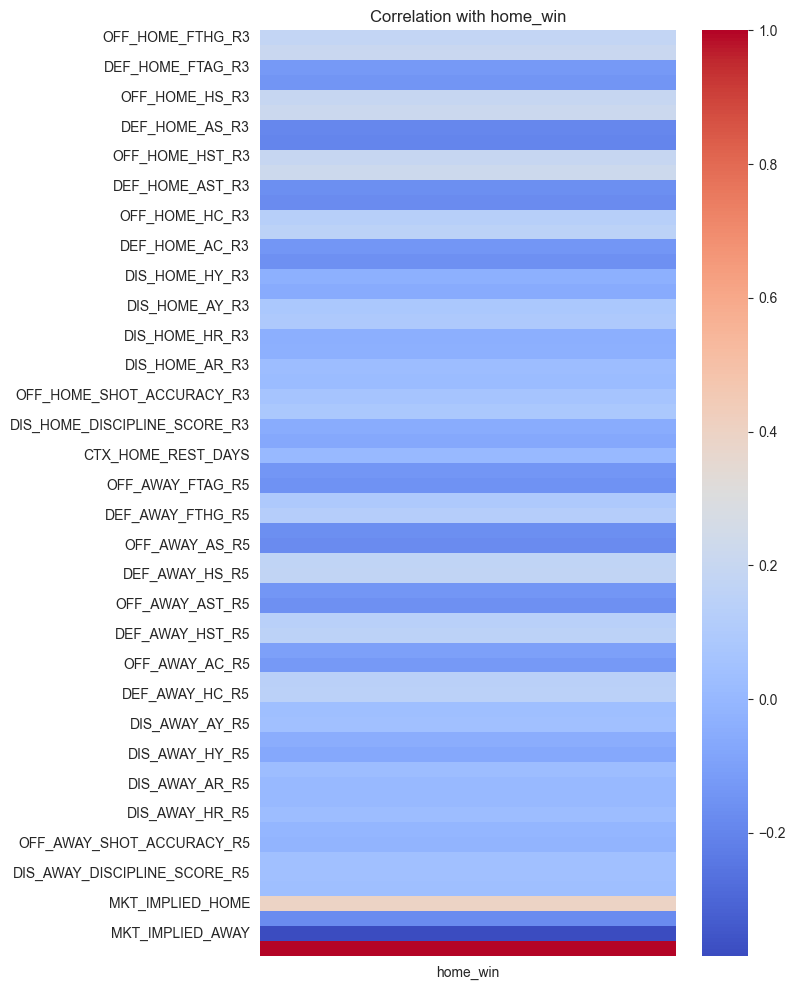

Potential leakage detected (|corr| > 0.8):


home_win    1.0
Name: home_win, dtype: float64

In [52]:
corr = df[feature_cols + [target_col]].corr(numeric_only=True)[target_col].sort_values(ascending=False)
display(corr.to_frame('corr_with_target'))

plt.figure(figsize=(8, 10))
sns.heatmap(df[feature_cols + [target_col]].corr(numeric_only=True)[[target_col]], annot=False, cmap='coolwarm')
plt.title('Correlation with home_win')
plt.tight_layout()
plt.show()

leak_flags = corr[abs(corr) > 0.8]
if not leak_flags.empty:
    print('Potential leakage detected (|corr| > 0.8):')
    display(leak_flags)
else:
    print('No high-correlation leakage flags detected.')

## Feature vs Target Boxplots

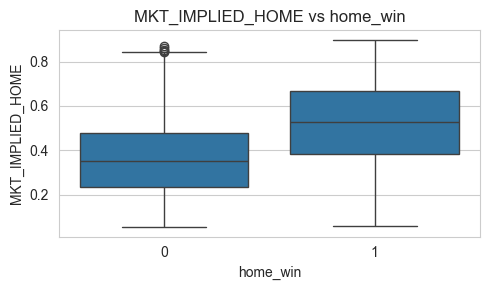

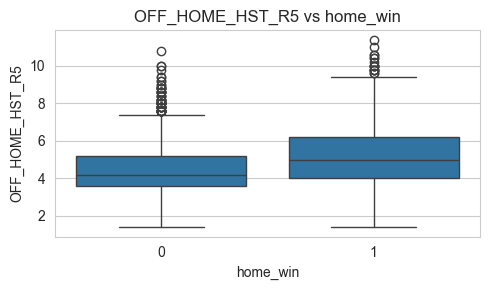

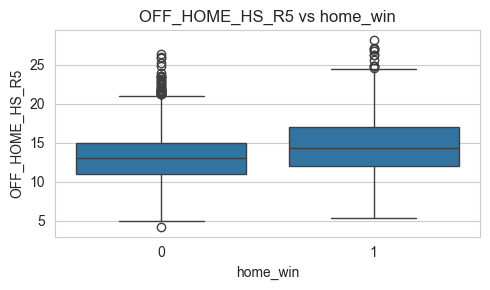

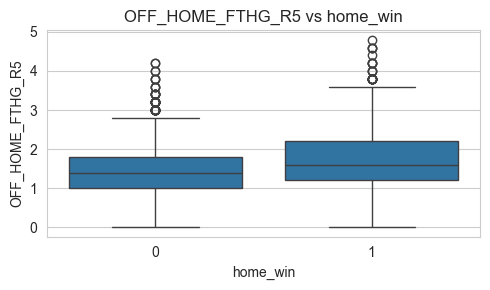

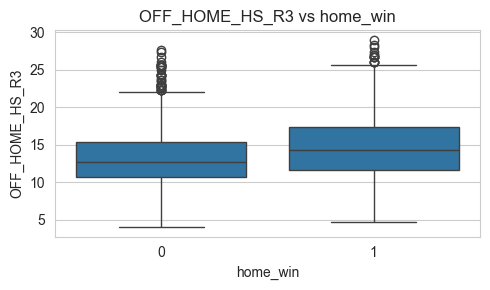

In [53]:
top5 = corr.drop(target_col).head(5).index.tolist()
for col in top5:
    plt.figure(figsize=(5, 3))
    sns.boxplot(x=target_col, y=col, data=df)
    plt.title(f'{col} vs {target_col}')
    plt.tight_layout()
    plt.show()

## Time-Series Consistency

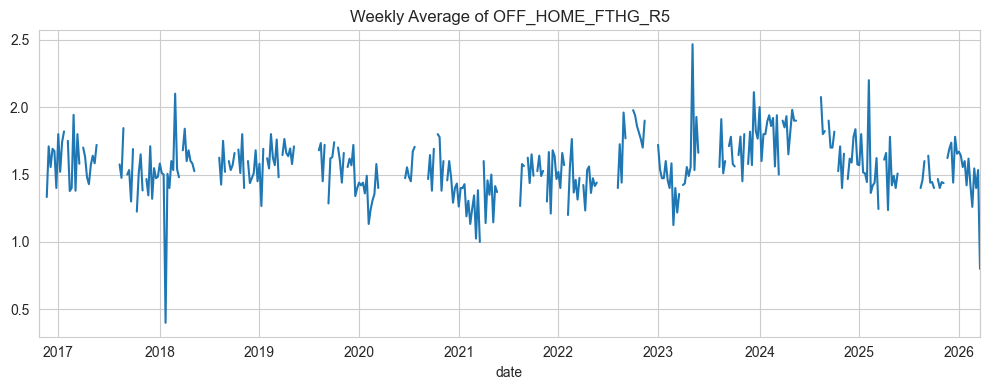

In [54]:
date_col = 'date' if 'date' in df.columns else 'Date'
df[date_col] = pd.to_datetime(df[date_col], errors='coerce')
ts_col = next((c for c in df.columns if c.startswith('OFF_') and c.endswith('_R5') and 'FTHG' in c), None)
if ts_col:
    ts = df[[date_col, ts_col]].dropna().sort_values(date_col)
    ts_grouped = ts.groupby(pd.Grouper(key=date_col, freq='W'))[ts_col].mean()
    plt.figure(figsize=(10, 4))
    ts_grouped.plot()
    plt.title(f'Weekly Average of {ts_col}')
    plt.tight_layout()
    plt.show()
else:
    print('No OFF_*FTHG*_R5 feature found for time-series plot.')

## Market Efficiency Check

/var/folders/5j/cgxgswl52bv6qlx0pdt0f8080000gn/T/ipykernel_77656/2296746224.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  calib = tmp.groupby('bin')[target_col].mean()


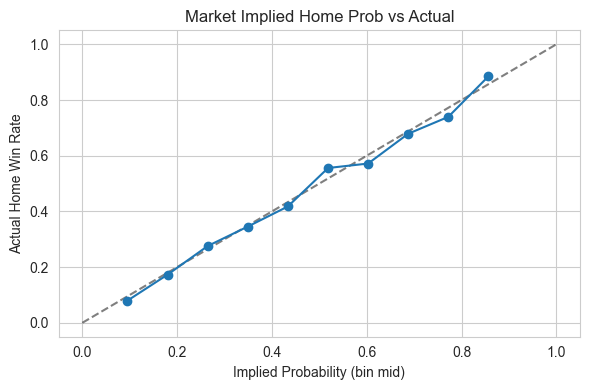

In [55]:
prob_col = next((c for c in df.columns if c.startswith('MKT_') and 'HOME' in c), None)
if prob_col:
    tmp = df[[prob_col, target_col]].dropna()
    tmp['bin'] = pd.cut(tmp[prob_col], bins=10)
    calib = tmp.groupby('bin')[target_col].mean()
    plt.figure(figsize=(6, 4))
    plt.plot([0, 1], [0, 1], 'k--', alpha=0.5)
    plt.plot(calib.index.map(lambda x: x.mid), calib.values, marker='o')
    plt.title('Market Implied Home Prob vs Actual')
    plt.xlabel('Implied Probability (bin mid)')
    plt.ylabel('Actual Home Win Rate')
    plt.tight_layout()
    plt.show()
else:
    print('No MKT_*HOME* feature found for calibration plot.')